# 1. Import Libraries


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Display settings
pd.set_option("display.max_columns", None) 
pd.set_option("display.max_rows", 100)

sns.set(style="whitegrid")

# 2. Load the Dataset and show first 5 rows


In [ ]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("talabat_enhanced_orders.csv")


df.head() #show first 5 rows

Saving talabat_enhanced_orders.csv to talabat_enhanced_orders (1).csv


,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,1,U3522,358,485,Fried Chicken,3,273.72,2025-06-16 08:32:00,2025-06-16 09:11:00,39,Alexandria,Wallet,Delivered,Motorbike,31.195082,29.921931,31.191404,29.904982,31.215658,29.910664,1.666106,High,Offline
1,2,U9214,316,65,Sandwich,3,365.82,2025-06-03 21:27:00,2025-06-03 22:00:00,33,Zagazig,Credit Card,Delivered,Motorbike,30.605729,31.503079,30.586047,31.485820,30.580329,31.502380,2.738698,Low,Online
2,3,U7307,357,309,Koshary,3,401.94,2025-06-01 14:48:00,2025-06-01 15:26:00,38,Assiut,Cash,In Transit,Car,27.190180,31.177741,27.164869,31.169218,27.162976,31.189458,2.929079,Medium,Online
3,4,U3612,420,32,Sushi,2,221.18,2025-06-13 02:30:00,2025-06-13 03:22:00,52,Mansoura,Cash,Delivered,Car,31.041846,31.381229,31.035773,31.380440,31.054690,31.401187,0.677498,Low,Online
4,5,U3492,73,364,Koshary,5,355.55,2025-06-06 09:48:00,2025-06-06 10:32:00,44,Mansoura,Wallet,Delivered,Motorbike,31.024141,31.376104,31.026023,31.396881,31.035350,31.389315,1.994769,High,Online


# 3. Basic Dataset Overview

In [ ]:
print("Dataset Shape:")
print(df.shape) #rows, columns

print("\nColumn Names:")
print(df.columns.tolist()) #converts the column names to a list

print("\nDataset Information:")
df.info() #summary of each column

Dataset Shape:
(100000, 23)

Column Names:
['Order_ID', 'User_ID', 'Restaurant_ID', 'Driver_ID', 'Item_Name', 'Quantity', 'Total_Price', 'Order_Time', 'Delivery_Time', 'Delivery_Duration_Minutes', 'City', 'Payment_Method', 'Order_Status', 'Driver_Vehicle', 'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat', 'Customer_Lon', 'Driver_Lat', 'Driver_Lon', 'Delivery_Distance_km', 'Traffic_Level', 'Driver_Availability']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Order_ID                   100000 non-null  int64  
 1   User_ID                    100000 non-null  object 
 2   Restaurant_ID              100000 non-null  int64  
 3   Driver_ID                  100000 non-null  int64  
 4   Item_Name                  100000 non-null  object 
 5   Quantity                   100000 non-null  int

# Show descriptive statistics for numerical columns

In [6]:
df.describe()

,Order_ID,Restaurant_ID,Driver_ID,Quantity,Total_Price,Delivery_Duration_Minutes,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,499.832850,250.791800,2.991110,268.925734,37.520110,30.119015,31.063065,30.119060,31.062971,30.119075,31.062993,2.165303
std,28867.657797,288.255257,144.289418,1.410132,170.490396,10.060876,1.271638,0.487754,1.271674,0.487811,1.271699,0.487826,1.038473
min,1.000000,1.000000,1.000000,1.000000,30.000000,15.000000,27.160900,29.898701,27.160900,29.898706,27.160901,29.898703,0.008839
25%,25000.750000,250.000000,126.000000,2.000000,129.430000,30.000000,30.023110,31.008774,30.023370,31.008460,30.023295,31.008410,1.355602
50%,50000.500000,499.000000,251.000000,3.000000,233.200000,38.000000,30.587306,31.209099,30.587054,31.208817,30.587085,31.209075,2.122694
75%,75000.250000,750.000000,376.000000,4.000000,381.510000,45.000000,31.026912,31.371676,31.027112,31.371856,31.027241,31.371508,2.924525
max,100000.000000,1000.000000,500.000000,5.000000,750.000000,60.000000,31.220099,31.521997,31.220096,31.521995,31.220099,31.521999,5.597928


# Show descriptive statistics for categorical columns

In [7]:
df.describe(include="object")

,User_ID,Item_Name,Order_Time,Delivery_Time,City,Payment_Method,Order_Status,Driver_Vehicle,Traffic_Level,Driver_Availability
count,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000
unique,9000,9,21367,21396,7,3,3,3,3,2
top,U1071,Shawarma,2025-06-07 07:23:00,2025-06-11 12:05:00,Zagazig,Cash,Delivered,Bicycle,Low,Online
freq,26,11320,16,15,14538,33528,85197,33393,45826,90111


# 4. Data Cleaning

In [8]:
# Check missing values
print("Missing Values Per Column:")
print(df.isnull().sum())

Missing Values Per Column:
Order_ID                     0
User_ID                      0
Restaurant_ID                0
Driver_ID                    0
Item_Name                    0
Quantity                     0
Total_Price                  0
Order_Time                   0
Delivery_Time                0
Delivery_Duration_Minutes    0
City                         0
Payment_Method               0
Order_Status                 0
Driver_Vehicle               0
Restaurant_Lat               0
Restaurant_Lon               0
Customer_Lat                 0
Customer_Lon                 0
Driver_Lat                   0
Driver_Lon                   0
Delivery_Distance_km         0
Traffic_Level                0
Driver_Availability          0
dtype: int64


# Check duplicate rows

In [9]:
print("Number of duplicated rows:")
print(df.duplicated().sum())

Number of duplicated rows:
0


# Remove duplicates if any exist

In [10]:
df = df.drop_duplicates()
print("Shape after removing duplicates:")
print(df.shape)

Shape after removing duplicates:
(100000, 23)


# Check data types


In [11]:
df.dtypes

,0
Order_ID,int64
User_ID,object
Restaurant_ID,int64
Driver_ID,int64
Item_Name,object
Quantity,int64
Total_Price,float64
Order_Time,object
Delivery_Time,object
Delivery_Duration_Minutes,int64


# 5. Convert Date/Time Columns

# Convert order and delivery time columns to datetime


In [12]:
df["Order_Time"] = pd.to_datetime(df["Order_Time"])
df["Delivery_Time"] = pd.to_datetime(df["Delivery_Time"])

# Confirm conversion


In [13]:
df[["Order_Time", "Delivery_Time"]].dtypes

,0
Order_Time,datetime64[ns]
Delivery_Time,datetime64[ns]



# 6. Feature Engineering



In [ ]:
# Extract useful time-based features from Order_Time
df["Order_Date"] = df["Order_Time"].dt.date
df["Order_Hour"] = df["Order_Time"].dt.hour
df["Order_Day"] = df["Order_Time"].dt.day_name()
df["Order_Month"] = df["Order_Time"].dt.month

# Calculate delivery duration again from time columns
# This helps us check if Delivery_Duration_Minutes is correct
df["Calculated_Delivery_Duration"] = (
    df["Delivery_Time"] - df["Order_Time"]
).dt.total_seconds() / 60

df[
    [
        "Order_Time",
        "Delivery_Time",
        "Delivery_Duration_Minutes",
        "Calculated_Delivery_Duration",
        "Order_Hour",
        "Order_Day",
    ]
].head() #displays the first 5 rows of the mentioned columns 

,Order_Time,Delivery_Time,Delivery_Duration_Minutes,Calculated_Delivery_Duration,Order_Hour,Order_Day
0,2025-06-16 08:32:00,2025-06-16 09:11:00,39,39.0,8,Monday
1,2025-06-03 21:27:00,2025-06-03 22:00:00,33,33.0,21,Tuesday
2,2025-06-01 14:48:00,2025-06-01 15:26:00,38,38.0,14,Sunday
3,2025-06-13 02:30:00,2025-06-13 03:22:00,52,52.0,2,Friday
4,2025-06-06 09:48:00,2025-06-06 10:32:00,44,44.0,9,Friday


# 7. Explore Categorical Columns

In [ ]:
categorical_columns = df.select_dtypes(include="object").columns #selects only columns that contain categorical data

for col in categorical_columns: #loops through each categorical column and prints the top 10 most frequent values in that column
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts().head(10))


Value counts for User_ID:
User_ID
U1071    26
U1830    25
U7534    24
U7436    23
U1041    23
U1689    23
U8326    23
U3625    23
U8228    22
U8083    22
Name: count, dtype: int64

Value counts for Item_Name:
Item_Name
Shawarma         11320
Pizza            11229
Fried Chicken    11171
Burger           11129
Pasta            11077
Sandwich         11061
Koshary          11033
Sushi            10990
Salad            10990
Name: count, dtype: int64

Value counts for City:
City
Zagazig       14538
Cairo         14381
Tanta         14336
Assiut        14302
Giza          14232
Alexandria    14167
Mansoura      14044
Name: count, dtype: int64

Value counts for Payment_Method:
Payment_Method
Cash           33528
Wallet         33250
Credit Card    33222
Name: count, dtype: int64

Value counts for Order_Status:
Order_Status
Delivered     85197
Cancelled      9812
In Transit     4991
Name: count, dtype: int64

Value counts for Driver_Vehicle:
Driver_Vehicle
Bicycle      33393
Car          33

# 8. Explore Numerical Columns

In [ ]:
numeric_columns = df.select_dtypes(include=np.number).columns #select numeric columns

print("Numerical columns:")
print(numeric_columns.tolist())

df[numeric_columns].describe()

Numerical columns:
['Order_ID', 'Restaurant_ID', 'Driver_ID', 'Quantity', 'Total_Price', 'Delivery_Duration_Minutes', 'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat', 'Customer_Lon', 'Driver_Lat', 'Driver_Lon', 'Delivery_Distance_km', 'Order_Hour', 'Order_Month', 'Calculated_Delivery_Duration']


,Order_ID,Restaurant_ID,Driver_ID,Quantity,Total_Price,Delivery_Duration_Minutes,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Order_Hour,Order_Month,Calculated_Delivery_Duration
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000
mean,50000.500000,499.832850,250.791800,2.991110,268.925734,37.520110,30.119015,31.063065,30.119060,31.062971,30.119075,31.062993,2.165303,11.479350,6.0,37.520110
std,28867.657797,288.255257,144.289418,1.410132,170.490396,10.060876,1.271638,0.487754,1.271674,0.487811,1.271699,0.487826,1.038473,6.924133,0.0,10.060876
min,1.000000,1.000000,1.000000,1.000000,30.000000,15.000000,27.160900,29.898701,27.160900,29.898706,27.160901,29.898703,0.008839,0.000000,6.0,15.000000
25%,25000.750000,250.000000,126.000000,2.000000,129.430000,30.000000,30.023110,31.008774,30.023370,31.008460,30.023295,31.008410,1.355602,5.000000,6.0,30.000000
50%,50000.500000,499.000000,251.000000,3.000000,233.200000,38.000000,30.587306,31.209099,30.587054,31.208817,30.587085,31.209075,2.122694,11.000000,6.0,38.000000
75%,75000.250000,750.000000,376.000000,4.000000,381.510000,45.000000,31.026912,31.371676,31.027112,31.371856,31.027241,31.371508,2.924525,17.000000,6.0,45.000000
max,100000.000000,1000.000000,500.000000,5.000000,750.000000,60.000000,31.220099,31.521997,31.220096,31.521995,31.220099,31.521999,5.597928,23.000000,6.0,60.000000


# 9. Visualization: Orders by City

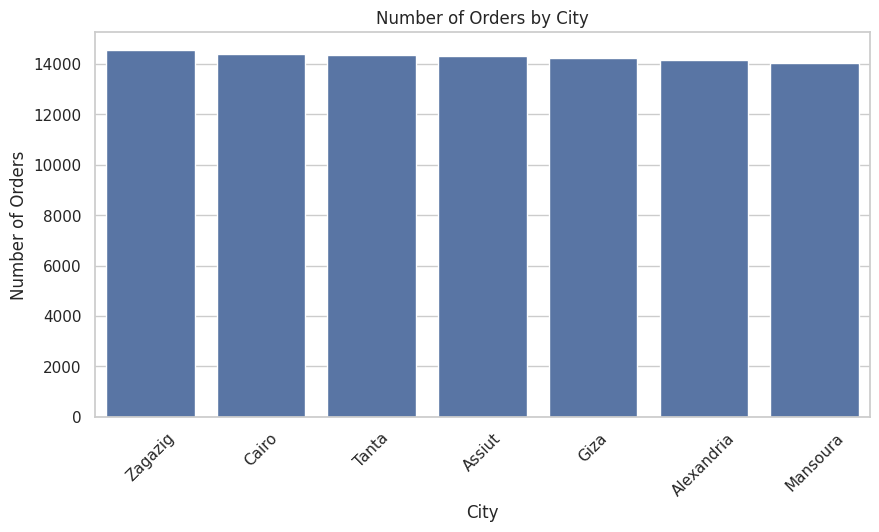

In [17]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="City", order=df["City"].value_counts().index)
plt.title("Number of Orders by City")
plt.xlabel("City")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

# 10. Visualization: Orders by Payment Method

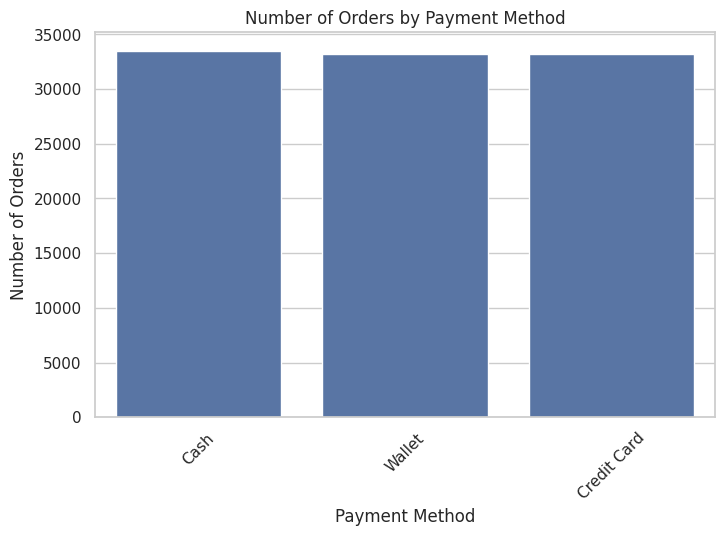

In [18]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="Payment_Method",
    order=df["Payment_Method"].value_counts().index
)
plt.title("Number of Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

# 11. Visualization: Order Status Distribution

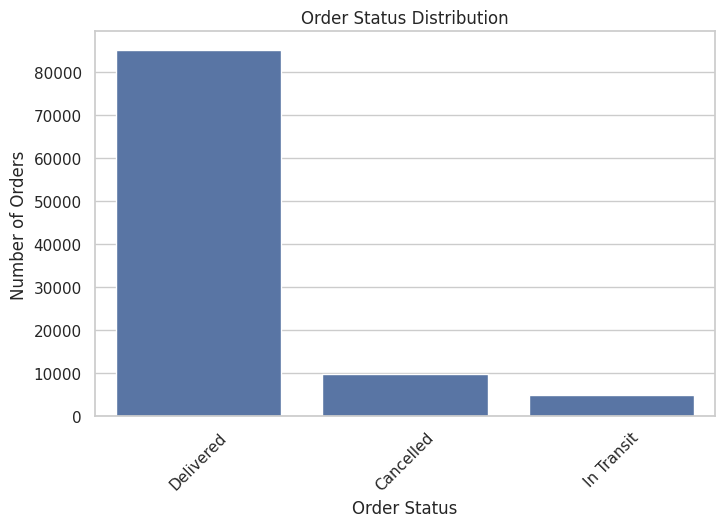

In [19]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="Order_Status",
    order=df["Order_Status"].value_counts().index
)
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

# 12. Visualization: Traffic Level Distribution

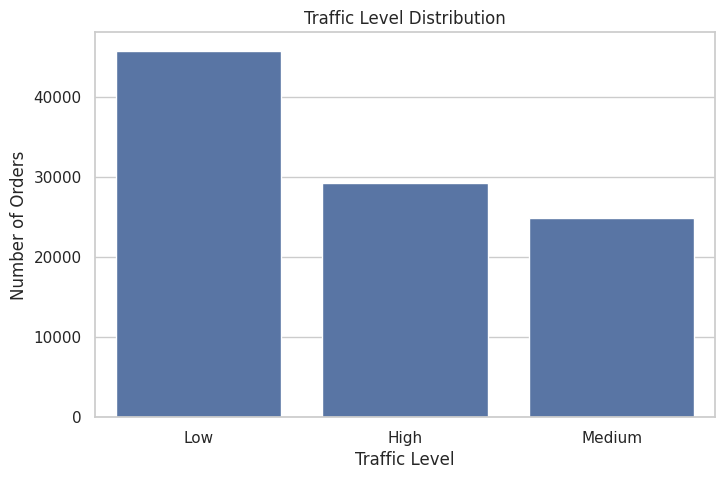

In [20]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="Traffic_Level",
    order=df["Traffic_Level"].value_counts().index
)
plt.title("Traffic Level Distribution")
plt.xlabel("Traffic Level")
plt.ylabel("Number of Orders")
plt.show()

Count plot was used here because the variables are categorical, which means that it has a fixed set of labels with no numeric values. The only thing we can do with categorical data is count how many times each category appears (frequency).

# 13. Visualization: Total Price Distribution

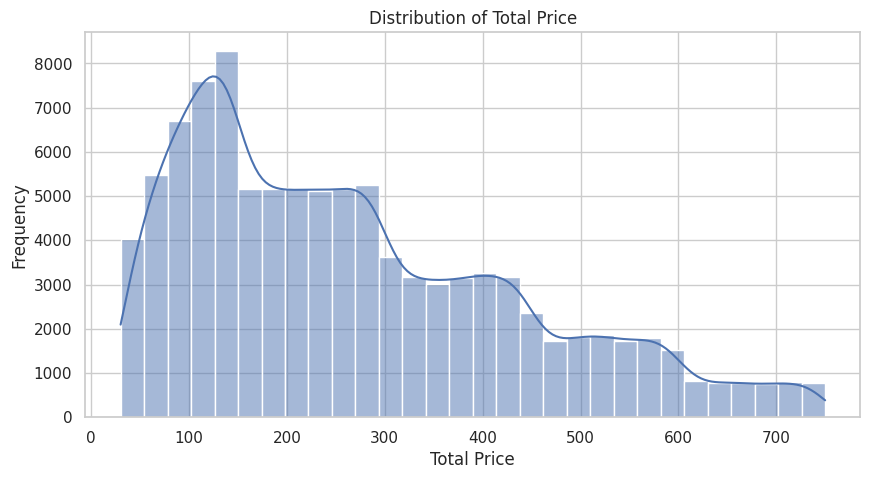

In [21]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Total_Price"], bins=30, kde=True)
plt.title("Distribution of Total Price")
plt.xlabel("Total Price")
plt.ylabel("Frequency")
plt.show()

# 14. Visualization: Delivery Duration Distribution

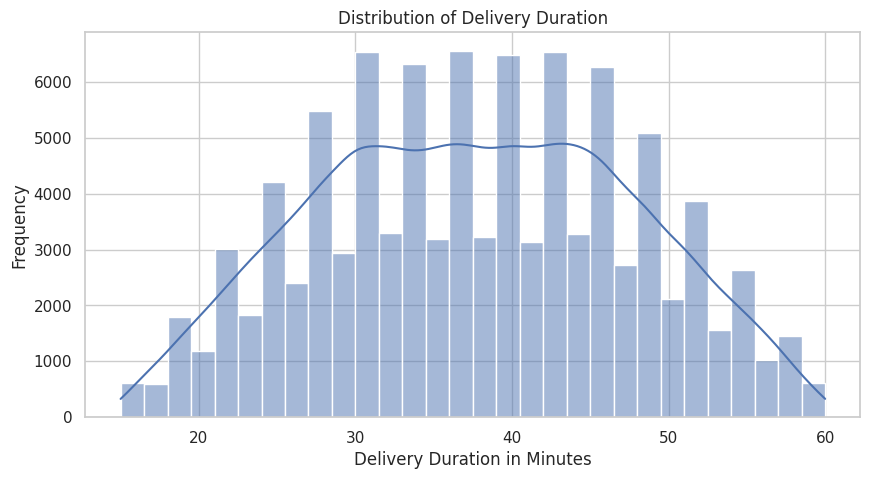

In [22]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Delivery_Duration_Minutes"], bins=30, kde=True)
plt.title("Distribution of Delivery Duration")
plt.xlabel("Delivery Duration in Minutes")
plt.ylabel("Frequency")
plt.show()

Histogram was used here since we're dealing with continuous numeric variables that can take hundreds of different values. We need to see how values are distributed, where are most values clustered, is the distribution skewed or symmetric, are there outliers? The kde adds a smooth curve on top, which makes the distribution shape easier to read.

# 15. Visualization: Total Price by Quantity

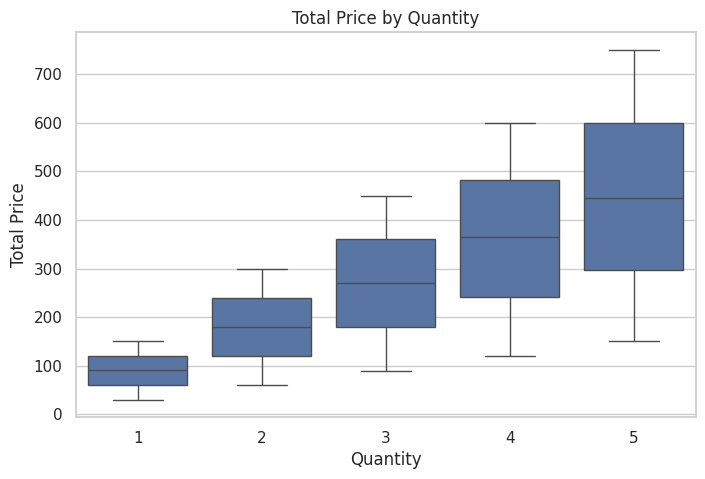

In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Quantity", y="Total_Price")
plt.title("Total Price by Quantity")
plt.xlabel("Quantity")
plt.ylabel("Total Price")
plt.show()

Box plot is used here because we're comparing numeric variable (price) to another variable (quantity). Box plot shows median, interquartile range, and outliers for each group, making it easy to spot differences between groups at a glance

# 16. Visualization: Average Delivery Duration by Traffic Level

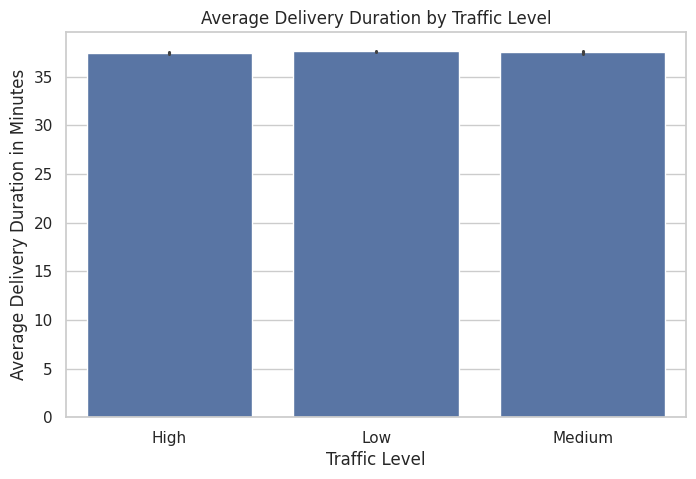

In [24]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Traffic_Level", y="Delivery_Duration_Minutes")
plt.title("Average Delivery Duration by Traffic Level")
plt.xlabel("Traffic Level")
plt.ylabel("Average Delivery Duration in Minutes")
plt.show()

# 17. Visualization: Average Delivery Duration by Driver Vehicle

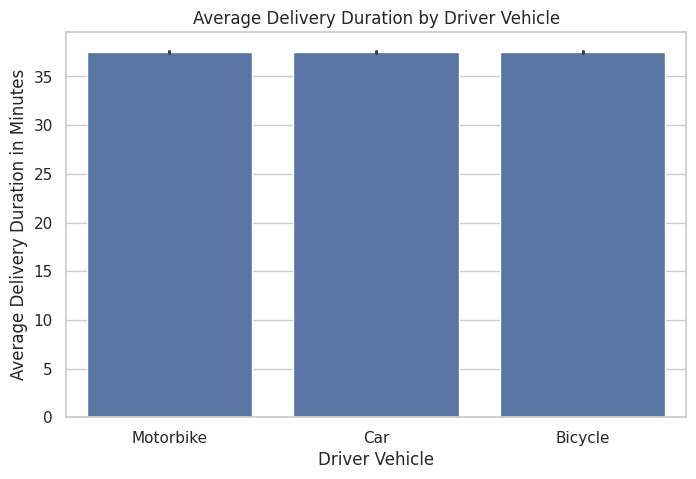

In [25]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Driver_Vehicle", y="Delivery_Duration_Minutes")
plt.title("Average Delivery Duration by Driver Vehicle")
plt.xlabel("Driver Vehicle")
plt.ylabel("Average Delivery Duration in Minutes")
plt.show()

Bar plt is used here because, similar to sections 9-12, we have a categorical x-axis but we're not just counting, we're computing the mean of a numeric variable per category.

# 18. Visualization: Orders by Hour of Day

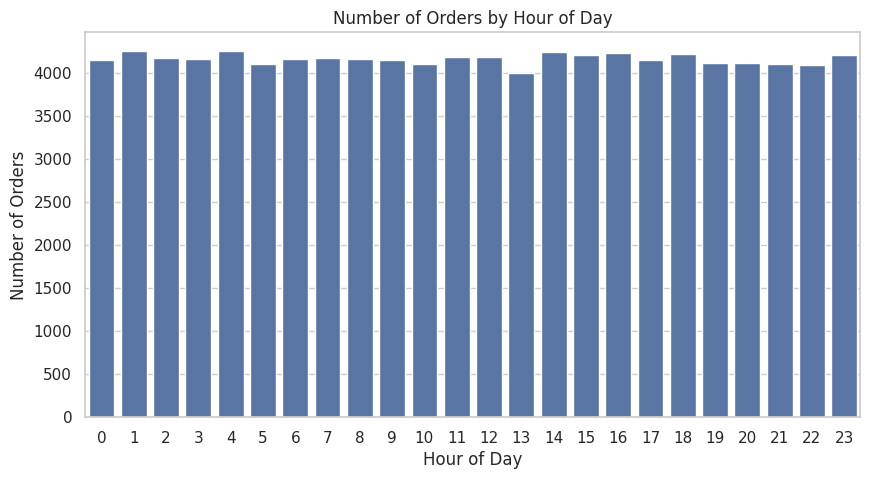

In [26]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Order_Hour")
plt.title("Number of Orders by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.show()

# 19. Visualization: Orders by Day of Week

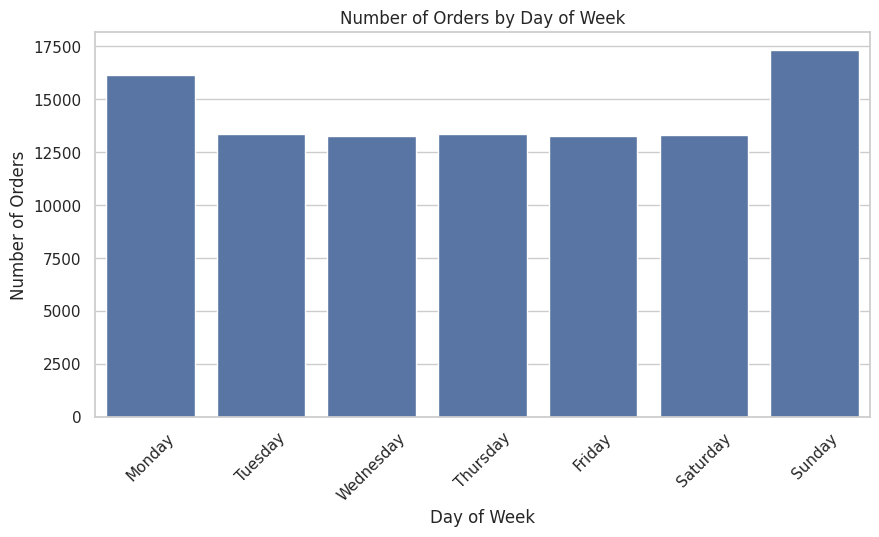

In [27]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Order_Day", order=day_order)
plt.title("Number of Orders by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

# 20. Correlation Matrix

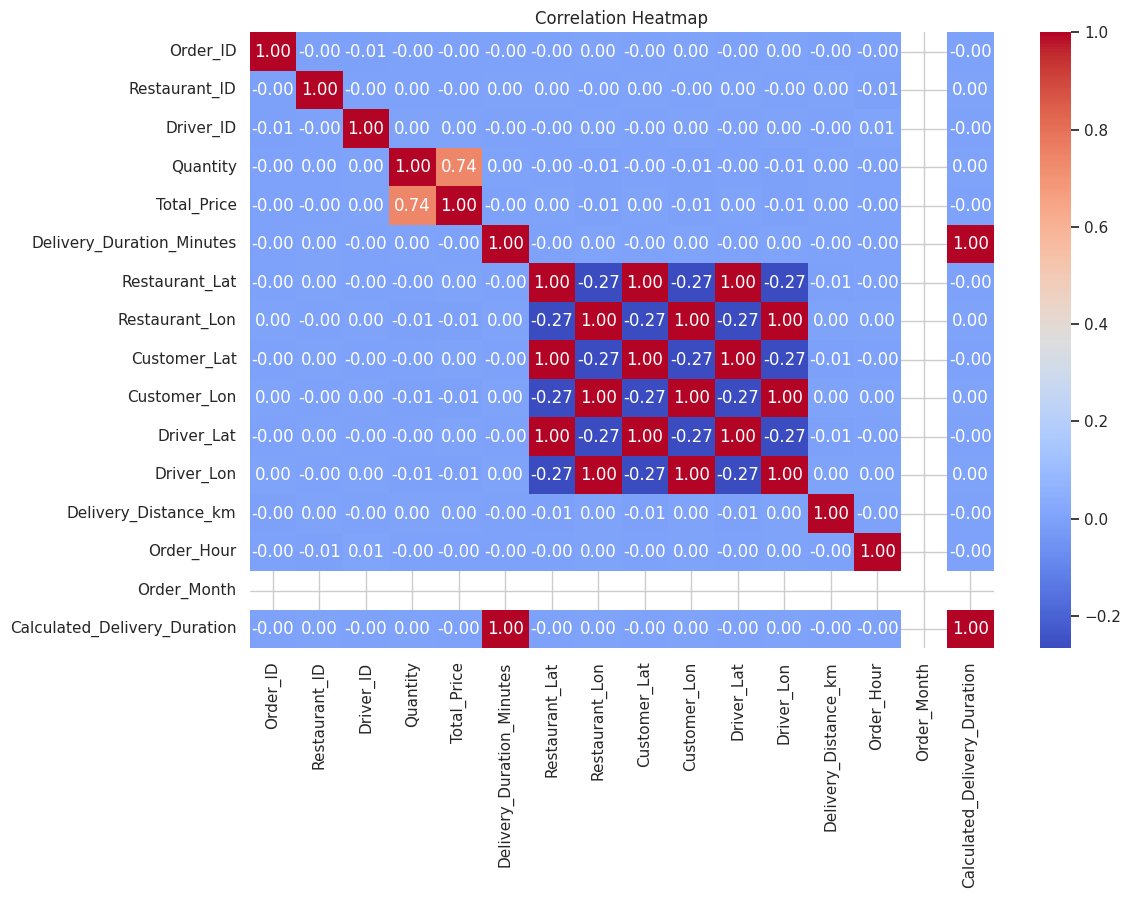

In [28]:
numeric_df = df.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Correlation matrix is a table of numbers between -1 and +1for every pair of numeric columns. It has been used to get a quick overview of the relationships between all numeric variablesin the dataset at once. Before running any hypothesis testing, we wnated to know which variables are realted to each other and how strongly. Using a heatmap with the correlation matrix makes the matrix easier to read by converting each number to a color, in our case red for strong positive correlation, blue for strong negative correlation, and light blue for near zero. We can spot types of relationships without having to go through the whole matrix number by number.

# 21. Helper Function for Hypothesis Test Decisions

In [29]:
def hypothesis_decision(p_value, alpha=0.05):
    """
    This function applies the decision rule for hypothesis testing.

    If p-value < alpha:
        Reject H0
    Else:
        Fail to reject H0
    """
    print(f"Significance level alpha = {alpha}")
    print(f"p-value = {p_value}")

    if p_value < alpha:
        print("Decision: Reject H0")
    else:
        print("Decision: Fail to reject H0")

# 22. Hypothesis Test 1: One-Sample t-Test

In [30]:
# Research Question:
# Is the average delivery duration significantly greater than 35 minutes?

# H0: μ <= 35
# H1: μ > 35

delivery_duration = df["Delivery_Duration_Minutes"].dropna()

sample_mean = delivery_duration.mean()

t_statistic, two_tailed_p_value = stats.ttest_1samp(delivery_duration, 35)

# Since this is a right-tailed test, divide the two-tailed p-value by 2
# But only if the sample mean is greater than the hypothesized mean
if sample_mean > 35:
    p_value = two_tailed_p_value / 2
else:
    p_value = 1 - (two_tailed_p_value / 2)

print("Hypothesis Test 1: One-Sample t-Test")
print("Question: Is the average delivery duration significantly greater than 35 minutes?")
print("H0: μ <= 35")
print("H1: μ > 35")

print("\nSample mean:")
print(sample_mean)

print("\nt-statistic:")
print(t_statistic)

hypothesis_decision(p_value)

if p_value < 0.05:
    print("\nConclusion: The average delivery duration is significantly greater than 35 minutes.")
else:
    print("\nConclusion: There is not enough evidence to say that the average delivery duration is greater than 35 minutes.")

Hypothesis Test 1: One-Sample t-Test
Question: Is the average delivery duration significantly greater than 35 minutes?
H0: μ <= 35
H1: μ > 35

Sample mean:
37.52011

t-statistic:
79.21067190240856
Significance level alpha = 0.05
p-value = 0.0
Decision: Reject H0

Conclusion: The average delivery duration is significantly greater than 35 minutes.


# 23. Hypothesis Test 2: ANOVA

In [ ]:
# Research Question:
# Does traffic level affect delivery duration?

# H0: The mean delivery duration is the same for all traffic levels.
# H1: At least one traffic level has a different mean delivery duration.

print("Traffic levels:")
print(df["Traffic_Level"].value_counts())

traffic_groups = [ 
    group["Delivery_Duration_Minutes"].dropna()
    for name, group in df.groupby("Traffic_Level")
] #groups data by each traffic level and collects the delievery duration values as a separate list

f_statistic, p_value = stats.f_oneway(*traffic_groups)

print("\nHypothesis Test 2: One-Way ANOVA")
print("Question: Does traffic level affect delivery duration?")
print("H0: Mean delivery duration is equal across all traffic levels")
print("H1: At least one traffic level has a different mean delivery duration")

print("\nMean delivery duration by traffic level:")
print(df.groupby("Traffic_Level")["Delivery_Duration_Minutes"].mean())

print("\nF-statistic:")
print(f_statistic)

hypothesis_decision(p_value)

if p_value < 0.05:
    print("\nConclusion: Delivery duration differs significantly between traffic levels.")
else:
    print("\nConclusion: There is no statistically significant difference in delivery duration between traffic levels.")

Traffic levels:
Traffic_Level
Low       45826
High      29220
Medium    24954
Name: count, dtype: int64

Hypothesis Test 2: One-Way ANOVA
Question: Does traffic level affect delivery duration?
H0: Mean delivery duration is equal across all traffic levels
H1: At least one traffic level has a different mean delivery duration

Mean delivery duration by traffic level:
Traffic_Level
High      37.450479
Low       37.582726
Medium    37.486655
Name: Delivery_Duration_Minutes, dtype: float64

F-statistic:
1.725322029358699
Significance level alpha = 0.05
p-value = 0.17812098619318947
Decision: Fail to reject H0

Conclusion: There is no statistically significant difference in delivery duration between traffic levels.


# 24. Hypothesis Test 3: Chi-Square Test of Independence

In [32]:
# Research Question:
# Is payment method related to order status?

# H0: Payment method and order status are independent.
# H1: Payment method and order status are dependent.

contingency_table = pd.crosstab(df["Payment_Method"], df["Order_Status"])

chi2_statistic, p_value, degrees_of_freedom, expected_values = stats.chi2_contingency(contingency_table)

print("Hypothesis Test 3: Chi-Square Test of Independence")
print("Question: Is payment method related to order status?")
print("H0: Payment method and order status are independent")
print("H1: Payment method and order status are dependent")

print("\nContingency table:")
print(contingency_table)

print("\nChi-square statistic:")
print(chi2_statistic)

print("\nDegrees of freedom:")
print(degrees_of_freedom)

hypothesis_decision(p_value)

if p_value < 0.05:
    print("\nConclusion: Payment method and order status have a statistically significant relationship.")
else:
    print("\nConclusion: There is no statistically significant relationship between payment method and order status.")

Hypothesis Test 3: Chi-Square Test of Independence
Question: Is payment method related to order status?
H0: Payment method and order status are independent
H1: Payment method and order status are dependent

Contingency table:
Order_Status    Cancelled  Delivered  In Transit
Payment_Method                                  
Cash                 3202      28618        1708
Credit Card          3340      28218        1664
Wallet               3270      28361        1619

Chi-square statistic:
6.4601753341514545

Degrees of freedom:
4
Significance level alpha = 0.05
p-value = 0.16731701892842205
Decision: Fail to reject H0

Conclusion: There is no statistically significant relationship between payment method and order status.


In [33]:
#Show expected values table for the Chi-Square test
expected_df = pd.DataFrame(
    expected_values,
    index=contingency_table.index,
    columns=contingency_table.columns
)

expected_df

Order_Status,Cancelled,Delivered,In Transit
Payment_Method,,,
Cash,3289.76736,28564.85016,1673.38248
Credit Card,3259.74264,28304.14734,1658.11002
Wallet,3262.49000,28328.00250,1659.50750


# 25. Hypothesis Test 4: Pearson Correlation Test

In [34]:
# Research Question:
# Is delivery distance correlated with delivery duration?

# H0: There is no linear correlation between delivery distance and delivery duration.
# H1: There is a significant linear correlation between delivery distance and delivery duration.

distance = df["Delivery_Distance_km"]
duration = df["Delivery_Duration_Minutes"]

correlation_coefficient, p_value = stats.pearsonr(distance, duration)

print("Hypothesis Test 4: Pearson Correlation Test")
print("Question: Is delivery distance correlated with delivery duration?")
print("H0: There is no linear correlation between delivery distance and delivery duration")
print("H1: There is a significant linear correlation between delivery distance and delivery duration")

print("\nCorrelation coefficient:")
print(correlation_coefficient)

hypothesis_decision(p_value)

if p_value < 0.05:
    print("\nConclusion: There is a statistically significant linear correlation between delivery distance and delivery duration.")
else:
    print("\nConclusion: There is no statistically significant linear correlation between delivery distance and delivery duration.")

Hypothesis Test 4: Pearson Correlation Test
Question: Is delivery distance correlated with delivery duration?
H0: There is no linear correlation between delivery distance and delivery duration
H1: There is a significant linear correlation between delivery distance and delivery duration

Correlation coefficient:
-0.0016781918097566843
Significance level alpha = 0.05
p-value = 0.5956373685501825
Decision: Fail to reject H0

Conclusion: There is no statistically significant linear correlation between delivery distance and delivery duration.


# Visualization for correlation test

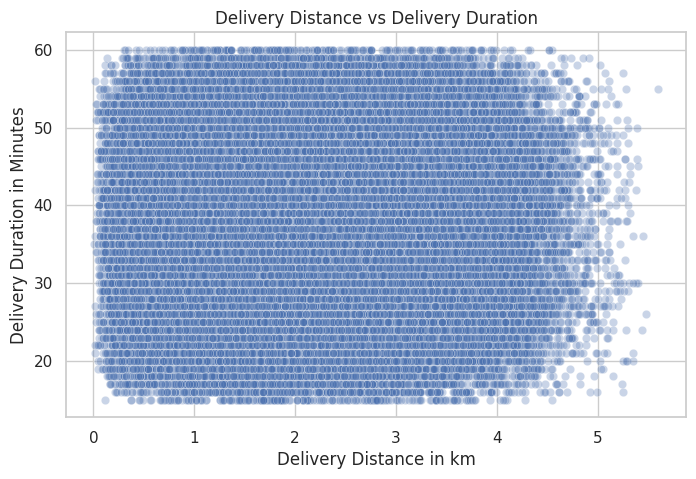

In [35]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Delivery_Distance_km", y="Delivery_Duration_Minutes", alpha=0.3)
plt.title("Delivery Distance vs Delivery Duration")
plt.xlabel("Delivery Distance in km")
plt.ylabel("Delivery Duration in Minutes")
plt.show()

This section compares two continuous numeric variables directly against each other(delievery distance and delievery duration). Each dot on a scatter plot represents one order plotted at its (distance, duration) coordinates; you can visually see whether a pattern or trend exists between the two. This directly supports the Pearson correlation test done in the same section: if there were a strong correlation, you'd expect to see the dots form a diagonal line.

# 26. Hypothesis Test 5: ANOVA

In [36]:
# Research Question:
# Does quantity affect total price?

# H0: The mean total price is the same for all quantity groups.
# H1: At least one quantity group has a different mean total price.

print("Quantity counts:")
print(df["Quantity"].value_counts().sort_index())

quantity_groups = [
    group["Total_Price"].dropna()
    for name, group in df.groupby("Quantity")
]

f_statistic, p_value = stats.f_oneway(*quantity_groups)

print("\nHypothesis Test 5: One-Way ANOVA")
print("Question: Does quantity affect total price?")
print("H0: Mean total price is equal across all quantity groups")
print("H1: At least one quantity group has a different mean total price")

print("\nMean total price by quantity:")
print(df.groupby("Quantity")["Total_Price"].mean())

print("\nF-statistic:")
print(f_statistic)

hypothesis_decision(p_value)

if p_value < 0.05:
    print("\nConclusion: Total price differs significantly between quantity groups.")
else:
    print("\nConclusion: There is no statistically significant difference in total price between quantity groups.")

Quantity counts:
Quantity
1    19945
2    20322
3    20124
4    19895
5    19714
Name: count, dtype: int64

Hypothesis Test 5: One-Way ANOVA
Question: Does quantity affect total price?
H0: Mean total price is equal across all quantity groups
H1: At least one quantity group has a different mean total price

Mean total price by quantity:
Quantity
1     89.982394
2    180.088135
3    270.030662
4    361.413322
5    447.078642
Name: Total_Price, dtype: float64

F-statistic:
30395.919612063055
Significance level alpha = 0.05
p-value = 0.0
Decision: Reject H0

Conclusion: Total price differs significantly between quantity groups.


# 27. More Useful Grouped Analysis

In [ ]:
# Average total price by city
df.groupby("City")["Total_Price"].mean().sort_values(ascending=False) #descending order
# Average delivery duration by city
df.groupby("City")["Delivery_Duration_Minutes"].mean().sort_values(ascending=False)
# Average delivery distance by city
df.groupby("City")["Delivery_Distance_km"].mean().sort_values(ascending=False)
# Most ordered items
df["Item_Name"].value_counts().head(10) #shows the 10 most frequently ordered items
# Payment method percentages
payment_percentages = df["Payment_Method"].value_counts(normalize=True) * 100
payment_percentages

,proportion
Payment_Method,
Cash,33.528
Wallet,33.250
Credit Card,33.222


# 28. Final Summary

In [ ]:
# ============================================================
# 28. Final Summary
# ============================================================

print("Final Project Summary")
print("---------------------")

print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicated rows:")
print(df.duplicated().sum())

print("\nAverage total price:")
print(df["Total_Price"].mean())

print("\nAverage delivery duration:")
print(df["Delivery_Duration_Minutes"].mean())

print("\nAverage delivery distance:")
print(df["Delivery_Distance_km"].mean())

print("\nMost common city:")
print(df["City"].mode()[0]) #returns the first most frequent value 

print("\nMost common payment method:")
print(df["Payment_Method"].mode()[0])

print("\nMost common order status:")
print(df["Order_Status"].mode()[0])

Final Project Summary
---------------------
Number of rows: 100000
Number of columns: 28

Missing values:
0

Duplicated rows:
0

Average total price:
268.9257336

Average delivery duration:
37.52011

Average delivery distance:
2.165303170085765

Most common city:
Zagazig

Most common payment method:
Cash

Most common order status:
Delivered


# 29. Final Written Conclusion

In [39]:
conclusion = """
In this project, the Talabat orders dataset was analyzed using Python.

The dataset contained 100,000 orders and 23 original columns.
There were no missing values and no duplicated rows, which means the dataset was already clean.

Exploratory data analysis was performed using descriptive statistics and visualizations.
The analysis included order counts by city, payment method, traffic level, and order status.
The distribution of total price and delivery duration was also explored.

Several hypothesis tests were applied using a significance level of alpha = 0.05.

Main results:
1. The one-sample t-test showed that the average delivery duration is significantly greater than 35 minutes.
2. The ANOVA test showed that delivery duration does not significantly differ between traffic levels.
3. The chi-square test showed that payment method and order status are not significantly related.
4. The Pearson correlation test showed no significant linear relationship between delivery distance and delivery duration.
5. The ANOVA test showed that total price differs significantly between quantity groups.

Overall, the dataset is useful for practicing data cleaning, exploratory data analysis, visualization, and hypothesis testing.
"""

print(conclusion)


In this project, the Talabat orders dataset was analyzed using Python.

The dataset contained 100,000 orders and 23 original columns. 
There were no missing values and no duplicated rows, which means the dataset was already clean.

Exploratory data analysis was performed using descriptive statistics and visualizations.
The analysis included order counts by city, payment method, traffic level, and order status.
The distribution of total price and delivery duration was also explored.

Several hypothesis tests were applied using a significance level of alpha = 0.05.

Main results:
1. The one-sample t-test showed that the average delivery duration is significantly greater than 35 minutes.
2. The ANOVA test showed that delivery duration does not significantly differ between traffic levels.
3. The chi-square test showed that payment method and order status are not significantly related.
4. The Pearson correlation test showed no significant linear relationship between delivery distance and d